In [1]:
from datetime import datetime, timedelta
import hashlib
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 500)
from sqlalchemy import create_engine, text
import plotly.graph_objects as go

from db_manager import ConnectionManager
cnxn = ConnectionManager()

In [2]:
def count_occupancy(df, start, end, garage_id=None, by_customer_type=True):
    """
    Counts the number of records active for each minute between start and end
    Parameters:
    df (DataFrame): A DataFrame with 'EntryDate' and 'ExitDate' as datetime columns.
    by_customer_type (bool): If True, returns counts broken down by customer type
    Returns:
    Series or DataFrame: If by_customer_type=False, returns Series with minute timestamps 
                        and total counts. If True, returns DataFrame with columns for each 
                        customer type.
    """
    # Define the full minute range
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    all_minutes = pd.date_range(start=start, end=end, freq='min')
    
    # Filter on garage
    if garage_id:
        df = df[df['GarageID']==garage_id].copy()
    
    # Clip Entry and Exit to the date range
    df['EntryDate'] = df['EntryDate'].clip(lower=start, upper=end)
    df['ExitDate'] = df['ExitDate'].clip(lower=start, upper=end)
    
    # Clean data
    #df = df.dropna(subset=['EntryDate', 'ExitDate'])
    #df = df[df['EntryDate'] < df['ExitDate']]
    
    if not by_customer_type:
        # Original logic - return total counts
        counts = pd.Series(0, index=all_minutes)
        entry_counts = df['EntryDate'].dt.floor('min').value_counts()
        exit_counts = df['ExitDate'].dt.ceil('min').value_counts()
        counts = counts.add(entry_counts, fill_value=0)
        counts = counts.subtract(exit_counts, fill_value=0)
        return counts.cumsum().astype(int)
    
    else:
        # New logic - return counts by customer type
        if 'customer_type' not in df.columns:
            raise ValueError("DataFrame must have 'customer_type' column when by_customer_type=True")
        
        df = df.dropna(subset=['customer_type'])
        customer_types = sorted(df['customer_type'].unique(), reverse=True)
        
        # Initialize DataFrame with all customer types
        result_df = pd.DataFrame(0, index=all_minutes, columns=customer_types)
        
        # Process each customer type separately
        for ctype in customer_types:
            ctype_df = df[df['customer_type'] == ctype]
            
            # Apply sweep line algorithm for this customer type
            counts = pd.Series(0, index=all_minutes)
            entry_counts = ctype_df['EntryDate'].dt.floor('min').value_counts()
            exit_counts = ctype_df['ExitDate'].dt.ceil('min').value_counts()
            counts = counts.add(entry_counts, fill_value=0)
            counts = counts.subtract(exit_counts, fill_value=0)
            
            result_df[ctype] = counts.cumsum().astype(int)
        
        return result_df

def prep_summary(df, start, end, garage_id, by_customer_type=True):
    summary = count_occupancy(df, start, end, garage_id=garage_id, by_customer_type=by_customer_type)
    if 'transient' not in summary.columns:
        summary['transient'] = 0
    if 'permit' not in summary.columns:
        summary['permit'] = 0
    if 'employee' not in summary.columns:
        summary['employee'] = 0
    summary['total'] = summary['transient'] + summary['permit'] + summary['employee']
    summary['GarageID'] = garage_id #[k for k,v in garages.items() if v==garage][0]
    summary['year'] = summary.index.year
    summary['quarter'] = summary.index.quarter
    summary['month'] = summary.index.month
    summary['week'] = summary.index.isocalendar().week
    summary['day'] = summary.index.day
    summary['dayofyear'] = summary.index.dayofyear
    summary['dayofweek'] = summary.index.dayofweek
    summary['hour'] = summary.index.hour
    summary['hms'] = summary.index.strftime('%H:%M:%S')
    summary['weekday_type'] = summary['dayofweek'].apply(lambda z: 1 if z<5 else 0)
    summary['period'] = summary['hour'].apply(lambda z: 'Daytime' if 6 <= z <= 18 else 'Evening')
    summary.loc[summary['hour'].between(6, 18), 'period'] = 'Daytime'
    summary.loc[~summary['hour'].between(6, 18), 'period'] = 'Evening'
    summary.loc[summary['dayofweek']>4, 'period'] = 'Weekend'
    
    return summary.iloc[:-1]

In [3]:
def prepare():
    start_date_by_garage = pd.read_sql("SELECT GarageID, max(date) max_date FROM dw.VisitSummary GROUP BY GarageID", cnxn.get_engine('PUReporting'))
    start = datetime.strftime(start_date_by_garage['max_date'].min(), '%Y-%m-%d %H:%M:%S')
    start_prior_min = datetime.strftime(start_date_by_garage['max_date'].min()-timedelta(minutes=1), '%Y-%m-%d %H:%M:%S')
    now = datetime.now()
    end = datetime.strftime(now, '%Y-%m-%d %H:%M:00')
    end_next_min = datetime.strftime(now + timedelta(minutes=1), '%Y-%m-%d %H:%M:00')
    start_date_by_garage = {a:b for a,b in zip(start_date_by_garage['GarageID'], start_date_by_garage['max_date'])}
    utils = {
        'start_date_by_garage': start_date_by_garage,
        'start': start,
        'start_prior_min': start_prior_min,
        'end': end,
        'end_next_min': end_next_min
    }
    return utils

In [4]:
def extract(start, end):
    # Step 1: Get last entry for each garage from dw.VisitSummary
    start_prior_min = datetime.strftime(pd.to_datetime(start) - timedelta(minutes=1), '%Y-%m-%d %H:%M:%S')
    
    current_state_of_visit_summary = pd.read_sql(f"""
        --SELECT v.*
        --FROM (SELECT DISTINCT GarageID FROM dw.VisitSummary) AS g
        --CROSS APPLY (
            --SELECT TOP 1 v.*
            --FROM dw.VisitSummary AS v
            --WHERE v.GarageID = g.GarageID
            --ORDER BY v.[date] DESC
        --) AS v
        --ORDER BY GarageID

        select * from dw.VisitSummary WHERE date = '{start_prior_min}' order by GarageID
        
        """, cnxn.get_engine('PUReporting')).sort_values('GarageID').set_index('date')
    
    # Step 2: Get transactions since last time the data was run
    df = pd.read_sql(f"""
        DECLARE @Id_Parking int
        DECLARE @fromDate datetime
        DECLARE @thruDate datetime
        DECLARE @impute_duration float
        
        set @Id_Parking = 1 -- Limit to a particular garage or lot
        set @fromDate = '{start}' -- Start of date range of interest
        set @thruDate = '{end}' -- End of date range of interest
        set @impute_duration = 204.0; -- in minutes. Use this to fill in NULL entry or exit. Represents the median length of stay. Is a best guess. 
        
        -- Step 1: TicketNumbers with any entry or exit at chosen location
        WITH TicketsWithActivity AS (
                SELECT DISTINCT TicketNumber
                FROM Opms.dbo.Transactions
                WHERE 
        		  CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) BETWEEN @fromDate AND @thruDate
                  AND TransactionType in (20, 30, 31, 33, 37, 40) --31, 37?
                  AND TicketNumber NOT IN (0, 31999, 410000000, 1100000000, 220000000,  610000000, 250000000, 810000000, 710000000)
            ),
            
            -- Step 2: Latest Entry (TransactionType = 20) for each TicketNumber
            LatestEntry AS (
                SELECT t.*
                FROM TicketsWithActivity a
                CROSS APPLY (
                    SELECT TOP 1 *
                    FROM Opms.dbo.Transactions
                    WHERE TicketNumber = a.TicketNumber
                      AND TransactionType = 20
                      --AND Id_parking = @Id_Parking
                      --AND TransactionDateStamp >= DATEADD(day, -1, @fromDate) AND TransactionDateStamp < @thruDate -- can look for entries up to one week prior to fromDate but don't want an entry after thruDate
        			  AND CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) BETWEEN @fromDate AND @thruDate
                    ORDER BY CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) DESC  -- Sort DESC to be conservative and take the entry closest to the date range start
                ) t
            ),
            
            -- Step 3: Latest Exit (TransactionType = 30) for each TicketNumber
            LatestExit AS (
                SELECT t.*
                FROM TicketsWithActivity a
                CROSS APPLY (
                    SELECT TOP 1 *
                    FROM Opms.dbo.Transactions
                    WHERE TicketNumber = a.TicketNumber
                      AND TransactionType = 30
                      --AND Id_parking = @Id_Parking
                      --AND TransactionDateStamp >= @fromDate AND TransactionDateStamp < DATEADD(day, 1, @thruDate) -- can look for exits up to month after the thruDate but don't want an exit before the fromDate
        			  AND CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) BETWEEN @fromDate AND @thruDate
                    ORDER BY CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) DESC
                ) t
            ),
            
            -- Step 4: Most recent failed or manual exit (TransactionType IN 31/33/37/40)
            LatestFailedOrManual AS (
                SELECT t.*
                FROM TicketsWithActivity a
                CROSS APPLY (
                    SELECT TOP 1 *
                    FROM Opms.dbo.Transactions
                    WHERE TicketNumber = a.TicketNumber
                      AND TransactionType IN (31, 33, 37, 40)
                      --AND Id_parking = @Id_Parking
                      --AND TransactionDateStamp >= @fromDate AND TransactionDateStamp < DATEADD(day, 1, @thruDate) -- can look for exits up to week after the thruDate but don't want an exit before the fromDate
        			  AND CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) BETWEEN @fromDate AND @thruDate
                    ORDER BY CONVERT(DATETIME, CONVERT(VARCHAR, CAST(TransactionDateStamp AS DATE), 120) + ' ' + TransactionTimeStamp) DESC 
                ) t
            ),
            
            -- Step 5: Bring in movements from SPM History in order to identify if parker is a permit holder
            PermitHolderMovements AS (
        		-- First gather data from permit holders who are no longer present but were at some point during the date range used
        		SELECT 
        			spm.iParkingId, pa.ParkingName, spm.lVirtualTicketNumber TicketNumber, 
                    CASE 
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.dtEntryDate
        			END dtEntryDate,
        			CASE 
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.sEntryTime
        			END sEntryTime,
        			CASE
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtExitDate AS DATE), 120) + ' ' + sExitTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.dtExitDate
        			END dtExitDate,
        			CASE
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtExitDate AS DATE), 120) + ' ' + sExitTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.sExitTime
        			END sExitTime,
        			sMediaNumber, c.sName CardHolder, g.sName GroupName, cu.sName CustomerName, cu.lId CustomerID, cAmountPaid, iEntryLocationId, iExitLocationId, eState
        	
        		FROM Opms.dbo.PresenceSpmHistory spm 
        		INNER JOIN Opms.dbo.ParkingAdmin pa On (spm.iParkingId=pa.Id_Parking)
        		LEFT JOIN ECounting.dbo.SPMCards c On (spm.sMediaNumber=c.sNumber)
        		LEFT JOIN Ecounting.dbo.SPMGroups g On (c.lGroupID=g.lId)
        		LEFT JOIN Ecounting.dbo.SPMCustomers cu On (g.lCustomerId=cu.lId)
        		WHERE
        			--spm.iParkingId = @Id_Parking
        			lVirtualTicketNumber != 0
        			AND ( -- Finds all permit visitors that came or went in the date range
                			CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) BETWEEN @fromDate AND @thruDate
                			OR CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtExitDate AS DATE), 120) + ' ' + sExitTime) BETWEEN @fromDate AND @thruDate
                		)
        			AND CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) != CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtExitDate AS DATE), 120) + ' ' + sExitTime)
        		UNION
        		-- This section brings in any present permit holders according to PresenceSPM
        		-- There is some bad data in this table. eState = 2 seems to be bad data where the entry/exit is out of whack
        		-- I also found some very old records that can't be true. It seems that when we delete a card from the system it can leave these abandoned records. Tying to current customers forces the table to drop those old/erroneous records.
        		SELECT 
        			spm.iParkingId, pa.ParkingName, spm.lVirtualTicketNumber TicketNumber, 
                    CASE 
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.dtEntryDate
        			END dtEntryDate,
        			CASE 
        				WHEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) NOT BETWEEN @fromDate AND @thruDate THEN NULL
        				ELSE spm.sEntryTime
        			END sEntryTime,
        			NULL dtExitDate,
        			NULL sExitTime,
        			sMediaNumber, c.sName CardHolder, g.sName GroupName, cu.sName CustomerName, cu.lId CustomerID, cAmountPaid, iEntryLocationId, iExitLocationId, eState
        	
        		FROM Opms.dbo.PresenceSpm spm
        		INNER JOIN Opms.dbo.ParkingAdmin pa On (spm.iParkingId=pa.Id_Parking)
        		LEFT JOIN ECounting.dbo.SPMCards c On (spm.sMediaNumber=c.sNumber)
        		INNER JOIN Ecounting.dbo.SPMGroups g On (c.lGroupID=g.lId)
        		INNER JOIN Ecounting.dbo.SPMCustomers cu On (g.lCustomerId=cu.lId)
        		WHERE
        			--spm.iParkingId = @Id_Parking
        			spm.lVirtualTicketNumber != 0
        			AND spm.eState != 2
                	AND ( -- Finds all permit visits that were present during any part of the date range
                		CONVERT(DATETIME, CONVERT(VARCHAR, CAST(dtEntryDate AS DATE), 120) + ' ' + sEntryTime) BETWEEN @fromDate AND @thruDate
                	)
        	),
            
            -- Step 6: Combine results with accurate status classification. This is where we get some attributes for the records that were selected
            PenultimateStep As (
                SELECT
                    COALESCE(e.Id_Parking, x.Id_Parking, fm.Id_Parking, spm.iParkingId) Id_Parking,
        			COALESCE(pa.ParkingName, spm.ParkingName) Garage,
                    --e.TicketNumber t1, x.TicketNumber t2, fm.TicketNumber t3, spm.TicketNumber t4,
                    CASE 
        				WHEN e.TicketNumber IS NOT NULL AND (x.TicketNumber IS NOT NULL OR fm.TicketNumber IS NOT NULL) THEN 'Complete'
        				WHEN spm.TicketNumber IS NOT NULL AND spm.dtEntryDate IS NOT NULL AND spm.dtExitDate IS NOT NULL THEN 'Complete'
                        WHEN spm.TicketNumber IS NOT NULL AND spm.dtEntryDate IS NULL THEN 'Exit Only'
        				WHEN spm.TicketNumber IS NOT NULL AND spm.dtExitDate IS NULL THEN 'Entry Only - Permit Holder' -- Added this changed classification so further parts of the query wouldn't automatically impute. These are customers known to still be present
        				WHEN e.TicketNumber IS NOT NULL AND x.TicketNumber IS NULL AND fm.TicketNumber IS NULL THEN 'Entry Only'
        				WHEN (x.TicketNumber IS NOT NULL OR fm.TicketNumber IS NOT NULL) AND e.TicketNumber IS NULL THEN 'Exit Only'
        				ELSE 'Unknown'
        			END AS status,
                    CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtEntryDate AS DATE), 120) + ' ' + spm.sEntryTime) spmEntryDate, 
        			CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtExitDate AS DATE), 120) + ' ' + spm.sExitTime) spmExitDate, 
        			spm.TicketNumber As TicketNumberSPM,
        			COALESCE(e.TicketNumber, x.TicketNumber, fm.TicketNumber) AS TicketNumber,
        			COALESCE(
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtEntryDate AS DATE), 120) + ' ' + spm.sEntryTime),
                        CONVERT(DATETIME, CONVERT(VARCHAR, CAST(e.TransactionDateStamp AS DATE), 120) + ' ' + e.TransactionTimeStamp)
        			) As EntryDate,
        			e.TransactionDateStamp,
        			e.TransactionTimeStamp,
        			COALESCE(
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtExitDate AS DATE), 120) + ' ' + spm.sExitTime),
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(x.TransactionDateStamp AS DATE), 120) + ' ' + x.TransactionTimeStamp)			
        			) AS ExitDate,
        			COALESCE(
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(fm.TransactionDateStamp AS DATE), 120) + ' ' + fm.TransactionTimeStamp), 
        				CONVERT(DATETIME, CONVERT(VARCHAR, CAST(spm.dtExitDate AS DATE), 120) + ' ' + spm.sExitTime)
        			) AS ExitAttemptDate,
        			CASE
        				--WHEN e.TransactionDateStamp IS NOT NULL THEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(e.TransactionDateStamp AS DATE), 120) + ' ' + e.TransactionTimeStamp)
        				WHEN e.TransactionDateStamp IS NULL AND x.TransactionDate > '2000-01-01' THEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(x.TransactionDate AS DATE), 120) + ' ' + x.TransactionTime)
        				WHEN e.TransactionDateStamp IS NULL AND fm.TransactionDate > '2000-01-01' THEN CONVERT(DATETIME, CONVERT(VARCHAR, CAST(fm.TransactionDate AS DATE), 120) + ' ' + fm.TransactionTime)
        				WHEN e.TransactionDateStamp IS NULL AND x.TransactionDate = '2000-01-01' AND fm.TransactionDate = '2000-01-01' THEN DATEADD(MINUTE, -@impute_duration, CONVERT(DATETIME, CONVERT(VARCHAR, CAST(x.TransactionDateStamp AS DATE), 120) + ' ' + x.TransactionTimeStamp))
        			END As EntryDate2,
        
        			CONVERT(DATETIME, CONVERT(VARCHAR, CAST(x.TransactionDate AS DATE), 120) + ' ' + x.TransactionTime) ExitOtherTimeStamp,
        			CONVERT(DATETIME, CONVERT(VARCHAR, CAST(fm.TransactionDate AS DATE), 120) + ' ' + fm.TransactionTime) ExitAttemptOtherTimeStamp,
        
        			e.TransactionType AS TransactionType_entry,
        			x.TransactionType AS TransactionType_exit, 
        			fm.TransactionType AS TransactionType_exit_attempt,
        
        			e.TicketType EntryTicketType,
        			CASE
        				WHEN e.TicketType = -1 THEN 'lost ticket'
        				WHEN e.TicketType = -11 THEN 'manual ticket'
        				WHEN e.TicketType = 0 THEN 'KP'
        				WHEN e.TicketType = 1 THEN 'value card'
        				WHEN e.TicketType = 2 THEN 'normal DP'
        				WHEN e.TicketType = 3 THEN 'congress'
        				WHEN e.TicketType = 4 THEN 'visitor'
        				WHEN e.TicketType = 5 THEN 'fixed time per day'
        				WHEN e.TicketType = 7 THEN 'fixed number of entries'
        				WHEN e.TicketType = 8 THEN 'pool car'
        				ELSE NULL
        			END As EntryTicketTypeDesc,
        			COALESCE(x.TicketType, fm.TicketType) ExitTicketType,
        			CASE
        				WHEN x.TicketType = -1 THEN 'lost ticket'
        				WHEN x.TicketType = -11 THEN 'manual ticket'
        				WHEN x.TicketType = 0 THEN 'KP'
        				WHEN x.TicketType = 1 THEN 'value card'
        				WHEN x.TicketType = 2 THEN 'normal DP'
        				WHEN x.TicketType = 3 THEN 'congress'
        				WHEN x.TicketType = 4 THEN 'visitor'
        				WHEN x.TicketType = 5 THEN 'fixed time per day'
        				WHEN x.TicketType = 7 THEN 'fixed number of entries'
        				WHEN x.TicketType = 8 THEN 'pool car'
        				WHEN x.TicketType IS NULL THEN CASE 
        												WHEN fm.TicketType = -1 THEN 'lost ticket'
        												WHEN fm.TicketType = -11 THEN 'manual ticket'
        												WHEN fm.TicketType = 0 THEN 'KP'
        												WHEN fm.TicketType = 1 THEN 'value card'
        												WHEN fm.TicketType = 2 THEN 'normal DP'
        												WHEN fm.TicketType = 3 THEN 'congress'
        												WHEN fm.TicketType = 4 THEN 'visitor'
        												WHEN fm.TicketType = 5 THEN 'fixed time per day'
        												WHEN fm.TicketType = 7 THEN 'fixed number of entries'
        												WHEN fm.TicketType = 8 THEN 'pool car'
        												WHEN fm.TicketType IS NULL THEN NULL
        												ELSE 'unknown'
        											END
        				ELSE 'unknown'
        			END As ExitTicketTypeDesc,
        			CASE
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -1 AND COALESCE(x.Amount, fm.Amount) = 0 AND COALESCE(x.T2Amount, fm.T2Amount) = 3000 AND COALESCE(x.IdCashier, fm.IdCashier) = 0 THEN 'lost ticket: POF' -- calc entry using best guess
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -1 AND COALESCE(x.Amount, fm.Amount) != 3000 AND COALESCE(x.IdCashier, fm.IdCashier) = 0 THEN 'lost ticket: help line' -- calc entry from best guess
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -1 AND COALESCE(x.Amount, fm.Amount) = 3000 AND COALESCE(x.IdCashier, fm.IdCashier) != 0 THEN 'lost ticket: cashier' --calc entry from best guess
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -1 AND COALESCE(x.Amount, fm.Amount) != 3000 AND COALESCE(x.IdCashier, fm.IdCashier) != 0 THEN 'manual: cashier' -- calc entry from OtherTimeStamp or Amount
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = 0 AND COALESCE(x.Parking, fm.Parking) = 0 AND COALESCE(x.Amount, fm.Amount) = 3000 AND COALESCE(x.IdCashier, fm.IdCashier) = 0 THEN 'lost ticket: help line' -- calc entry from best guess
        				WHEN e.TransactionDateStamp IS NULL AND SUBSTRING(CAST(COALESCE(x.TicketNumber, fm.TicketNumber) AS VARCHAR(9)),3,1) = 9 THEN 'permit: no entry found'
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TicketType) = -11 AND COALESCE(x.IdCashier, fm.IdCashier) != 0 THEN 'manual: cashier' -- calc entry from OtherTimeStamp or Amount
        				WHEN e.TransactionDateStamp IS NULL AND COALESCE(x.TicketType, fm.TIcketType) = 0 AND COALESCE(x.IdCashier, fm.IdCashier) = 0 THEN 'manual: help line' -- calc entry from OtherTimeStamp
        				WHEN e.TransactionDateStamp IS NULL AND SUBSTRING(CAST(COALESCE(x.TicketNumber, fm.TicketNumber) AS VARCHAR(9)),3,3) = '000' AND x.TransactionType = 30 AND spm.sMediaNumber IS NOT NULL THEN 'permit: manual help line exit'
        				WHEN e.TransactionDateStamp IS NULL AND spm.sMediaNumber IS NOT NULL AND COALESCE(x.Parking, fm.Parking) = 1 AND x.TransactionType = 30 THEN 'permit: manual exit'
        				WHEN e.TransactionDateStamp IS NOT NULL AND (x.TransactionDateStamp IS NOT NULL OR fm.TransactionDateStamp IS NOT NULL OR spm.dtExitDate IS NOT NULL) THEN NULL
        				WHEN spm.dtEntryDate IS NOT NULL AND spm.dtExitDate IS NULL THEN NULL -- applies to present permit holders
        				WHEN spm.dtEntryDate IS NOT NULL AND spm.dtExitDate IS NOT NULL THEN NULL
        				--WHEN e.TransactionDateStamp IS NOT NULL AND x.TransactionDateStamp IS NULL AND fm.TransactionDateStamp IS NULL AND spm.dtExitDate IS NULL THEN 'imputed' -- Do I want to have something here? Simply means status is Entry Only
        				ELSE NULL
        			END As exit_classification,
        	
        			e.Parking Parking_entry,
        			x.Parking Parking_exit, 
        			fm.Parking Parking_exit_attempt,
        	
        			COALESCE(x.Amount, fm.Amount)/100. Amount, 
        			COALESCE(x.T2Amount, fm.T2Amount)/100. T2Amount, 
        	
        			COALESCE(x.IdCashier, fm.IdCashier) IdCashier, 
        			COALESCE(x.IdShift, fm.IdShift) IdShift,	
        
        			e.T2StationAdddress EntryStation,
        			x.T2StationAdddress ExitStation, 
        			fm.T2StationAdddress ExitAttemptStation,
        			spm.sMediaNumber,
        			spm.CardHolder, 
        			spm.GroupName, 
        			spm.CustomerName, 
        			spm.CustomerID, 
        			CASE
        				WHEN spm.sMediaNumber IS NULL THEN 'transient'
        				WHEN spm.sMediaNumber IS NOT NULL AND spm.CustomerID = 929 THEN 'employee'
        				ELSE 'permit'
        			END As customer_type
        
                FROM TicketsWithActivity a
                LEFT JOIN LatestEntry e ON a.TicketNumber = e.TicketNumber
                LEFT JOIN LatestExit x ON a.TicketNumber = x.TicketNumber
                LEFT JOIN LatestFailedOrManual fm ON a.TicketNumber = fm.TicketNumber
                LEFT JOIN Opms.dbo.ParkingAdmin pa On (COALESCE(e.Id_Parking, x.Id_Parking, fm.Id_Parking)=pa.Id_Parking)
                FULL OUTER JOIN PermitHolderMovements spm On (a.TicketNumber = spm.TicketNumber AND e.TransactionDateStamp=spm.dtEntryDate AND e.TransactionTimeStamp=spm.sEntryTime
                                                        OR a.TicketNumber = spm.TicketNumber AND x.TransactionDateStamp=spm.dtExitDate AND x.TransactionTimeStamp=spm.sExitTime
                                                        OR a.TicketNumber = spm.TicketNumber AND fm.TransactionDateStamp=spm.dtExitDate AND fm.TransactionTimeStamp=spm.sExitTime
                                                        )
        		
            ),
        
        -- Final BatchData CTE that wraps everything
        BatchData AS (
            SELECT 
                --t1, t2, t3, t4,
        		CASE
        			WHEN status = 'Exit Only' AND EntryDate2 > ExitDate THEN CONVERT(VARCHAR(32), HASHBYTES('MD5', CONCAT(Id_Parking, '_', COALESCE(TicketNumber, TicketNumberSPM), '_', ISNULL(CONVERT(VARCHAR, DATEADD(MINUTE, -@impute_duration, ExitDate), 121), 'NULL'))), 2)
        			WHEN status = 'Exit Only' AND DATEDIFF(DAY, EntryDate2, ExitDate) > 8 THEN  CONVERT(VARCHAR(32), HASHBYTES('MD5', CONCAT(Id_Parking, '_', COALESCE(TicketNumber, TicketNumberSPM), '_', ISNULL(CONVERT(VARCHAR, DATEADD(MINUTE, -@impute_duration, ExitDate), 121), 'NULL'))), 2) -- Added this line. A transient vehicle should not be in the garage for more than 2 weeks. There is data with an exit only that has a EntryDate2 that was 7 years earlier.
        			ELSE CONVERT(VARCHAR(32), HASHBYTES('MD5', CONCAT(Id_Parking, '_', COALESCE(TicketNumber, TicketNumberSPM), '_', ISNULL(CONVERT(VARCHAR, COALESCE(EntryDate, EntryDate2, spmEntryDate), 121), 'NULL'))), 2)
        		END As TripDetailID,
                Id_Parking as GarageID,
                Garage,
                status,
                COALESCE(TicketNumber, TicketNumberSPM) TicketNumber, -- Ticket Number	
        		-- Calculate the final EntryDate
                CASE
                    --WHEN status = 'Exit Only' AND EntryDate2 > ExitDate THEN DATEADD(MINUTE, -@impute_duration, ExitDate)
        			--WHEN status = 'Exit Only' AND DATEDIFF(DAY, EntryDate2, ExitDate) > 8 THEN DATEADD(MINUTE, -@impute_duration, ExitDate)
                    WHEN status = 'Exit Only' THEN NULL
                    ELSE COALESCE(EntryDate, EntryDate2, spmEntryDate)
                END As EntryDate,
                EntryDate2, spmEntryDate,
                -- Calculate the final ExitDate
        		CASE 
                    WHEN status = 'Entry Only' AND EntryDate >= CONCAT(SUBSTRING(CONVERT(VARCHAR, GETDATE(), 120),1,10),' 00:00:00') THEN NULL -- if EntryDate is same day and status is Entry Only, leave exit blank
                    --WHEN status = 'Entry Only' THEN DATEADD(MINUTE, @impute_duration, EntryDate) -- otherwise impute ExitDate
                    ELSE COALESCE(ExitDate, ExitAttemptDate, spmExitDate) 
                END As ExitDate,
                CASE
                    --WHEN status = 'Exit Only' AND EntryDate2 > ExitDate THEN @impute_duration
        			--WHEN status = 'Exit Only' AND DATEDIFF(DAY, EntryDate2, ExitDate) > 8 THEN @impute_duration
                    --WHEN status = 'Entry Only' THEN @impute_duration
                    WHEN status = 'Exit Only' THEN NULL
                    WHEN status LIKE 'Entry Only%' THEN NULL
                    ELSE DATEDIFF(second, COALESCE(EntryDate, EntryDate2, spmEntryDate), COALESCE(ExitDate, ExitAttemptDate, spmExitDate))/60. 
                END As length_of_stay,
                --CASE
                    --WHEN status = 'Exit Only' AND EntryDate2 > ExitDate THEN @impute_duration
        			--WHEN status = 'Exit Only' AND DATEDIFF(DAY, EntryDate2, ExitDate) > 8 THEN @impute_duration
                    --WHEN status = 'Entry Only' THEN @impute_duration
                    --WHEN status = 'Exit Only' THEN NULL
                    --WHEN status LIKE 'Entry Only%' THEN NULL
                    --WHEN status = 'Exit Only' AND COALESCE(ExitOtherTimeStamp, ExitAttemptOtherTimeStamp) = '2000-01-01 00:00:00' THEN @impute_duration
                    --ELSE NULL
                --END AS impute_duration,
                NULL As impute_duration,
                customer_type,
                exit_classification,
                COALESCE(TransactionType_exit, TransactionType_exit_attempt) TransactionType_exit,
                EntryTicketType TicketType_entry,
                EntryTicketTypeDesc TicketTypeDesc_entry,
                ExitTicketType TicketType_exit,
                ExitTicketTypeDesc TicketTypeDesc_exit,
                Parking_entry,
                COALESCE(Parking_exit, Parking_exit_attempt) Parking_exit,
                Amount,
                T2Amount,
                IdCashier,
                IdShift,
                EntryStation,
                ExitStation, 
        		ExitAttemptStation,
                sMediaNumber As PermitNumber,
                CardHolder As PermitName,
                GroupName,
                CustomerName,
                CustomerID,
                'ZMS' As SourceSystem,
                GETDATE() As LoadDate
        
            FROM PenultimateStep
        	WHERE (TicketNumber IS NOT NULL OR TicketNumberSPM IS NOT NULL)
        )
        SELECT * FROM BatchData
        ORDER BY EntryDate""", cnxn.get_engine('opms'))
    return current_state_of_visit_summary, df

In [5]:
def garage_summary(merged, start: str, end_next_min: str, garages: dict):
    garage_summary_dict = {k:prep_summary(merged, start, end_next_min, k, True) for k,v in garages.items()}
    return garage_summary_dict

In [ ]:
def build_summary_data(current_state_of_visit_summary, garage_summary_dict, garages):
    summary_data = pd.DataFrame()
    for garage_id in garages.keys():
        temp = pd.concat([current_state_of_visit_summary.query('GarageID==@garage_id'), garage_summary_dict[garage_id]])
        temp.fillna({'transient':0, 'permit':0, 'employee':0},inplace=True)
        temp['total'] = temp['transient'] + temp['permit'] + temp['employee']
        
        temp['new_transient'] = temp['transient'].iloc[0] + temp['transient']
        temp['new_permit'] = temp['permit'].iloc[0] + temp['permit']
        temp['new_employee'] = temp['employee'].iloc[0] + temp['employee']
        temp['new_total'] = temp['total'].iloc[0] + temp['total']

        summary_data = pd.concat([summary_data, temp.iloc[1:]])
    
    return summary_data

In [ ]:
def transform(df, start, end_next_min, current_state_of_visit_summary, garages):
    # Step 1: Prep dataset
    df.loc[df['EntryDate']<start, 'EntryDate'] = None
    
    # Step 2: 
    garage_summary_dict = garage_summary(df, start, end_next_min, garages)

    # Step 3:
    summary_data = build_summary_data(current_state_of_visit_summary, garage_summary_dict, garages)
    
    return summary_data

In [8]:
def sql_md5_hash(Id_Parking, TicketNumber=None, EntryDate=None):
    # Emulate SQL COALESCE/ISNULL logic
    ticket = TicketNumber
    entry = EntryDate
    
    # SQL ISNULL(CONVERT(VARCHAR, date, 121), 'NULL')
    if entry is not None:
        if isinstance(entry, datetime):
            entry_str = entry.strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # ODBC style: yyyy-mm-dd hh:mm:ss.mmm
        else:
            entry_str = str(entry)
    else:
        entry_str = 'NULL'
    print(entry_str)
    # SQL CONCAT(Id_Parking, '_', ticket, '_', entry_str)
    concat_str = f"{Id_Parking}_{ticket}_{entry_str}"

    # MD5 hash (same as HASHBYTES('MD5', ...))
    md5_hash = hashlib.md5(concat_str.encode('utf-8')).hexdigest().upper()

    return md5_hash

In [ ]:
def load_summary(summary, start_date_by_garage):
    # Delete per garage so a lagging garage doesn't wipe ahead-of-schedule garages
    with cnxn.get_engine('PUReporting').begin() as conn:
        print(f"Deleting old records...")
        deleted = 0
        for garage_id, start_date in start_date_by_garage.items():
            r = conn.execute(
                text("DELETE FROM dw.VisitSummary WHERE GarageID = :gid AND date >= :last_entry"),
                {"gid": garage_id, "last_entry": start_date}
            )
            deleted += r.rowcount
        print(f"Deleted {deleted} records")

    with cnxn.get_engine('PUReporting').begin() as conn:
        start_insert_time = datetime.now()
        print(f"Inserting new records ({start_insert_time})")
        insert_result = summary[['GarageID', 'new_transient', 'new_permit', 'new_employee', 'new_total', 'year', 'quarter', 'month', 'week', 'day', 'dayofyear', 'dayofweek', 'hour', 'hms', 'weekday_type', 'period']]\
            .reset_index().rename(columns={'index':'date', 'new_transient':'transient', 'new_permit':'permit', 'new_employee':'employee', 'new_total':'total'})\
            .to_sql('VisitSummary', schema='dw', con=cnxn.get_engine('PUReporting'), if_exists='append', index=False, chunksize=1000)
        print(f"Inserted {summary.shape[0]} records")
        print("Insert completed successfully!")
        return insert_result

## Build Garage Dict

In [10]:
garages = pd.read_sql("SELECT Id_Parking, ParkingName garage FROM ParkingAdmin WHERE Id_Parking NOT IN (7, 9)", cnxn.get_engine('opms'))
garages = {a:b for a,b in zip(garages.Id_Parking, garages.garage)}
garages

{1: 'Overture Center',
 2: 'State St Capitol Upper',
 5: 'Lake/Frances',
 6: 'Capitol Square North',
 12: 'State St Capitol  Lower',
 18: 'Livingston',
 19: 'Wilson Street'}

## Collect Important Dates

In [11]:
utils = prepare()
utils

{'start_date_by_garage': {1: Timestamp('2025-12-10 15:10:00'),
  2: Timestamp('2025-12-10 15:10:00'),
  5: Timestamp('2025-12-10 15:10:00'),
  6: Timestamp('2025-12-10 15:10:00'),
  12: Timestamp('2025-12-10 15:10:00'),
  18: Timestamp('2025-12-10 15:10:00'),
  19: Timestamp('2025-12-10 15:10:00')},
 'start': '2025-12-10 15:10:00',
 'start_prior_min': '2025-12-10 15:09:00',
 'end': '2025-12-12 09:20:00',
 'end_next_min': '2025-12-12 09:21:00'}

In [15]:
#utils['end'] = '2025-10-28 08:12:00'
#utils['end_next_min'] = '2025-10-29 11:24:00'

In [12]:
t1 = datetime.now()

current_state_of_visit_summary, e = extract(utils['start'], utils['end'])

t = transform(e, utils['start'], utils['end_next_min'], current_state_of_visit_summary, garages)

load_date = datetime.strftime(datetime.now(), '%Y:%m:%d %H:%M:%S')
e['newLoadDate'] = datetime.now()

t2 = datetime.now()

print(f"This process lasted {round((t2 - t1).total_seconds(),1)} seconds")

This process lasted 12.6 seconds


In [13]:
num1 = t.shape[0]/7
print(num1)
assert num1.is_integer()

2531.0


In [14]:
e.shape

(7648, 35)

In [15]:
e['status'].value_counts()

status
Complete                      5200
Exit Only                     1343
Entry Only                     709
Entry Only - Permit Holder     396
Name: count, dtype: int64

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


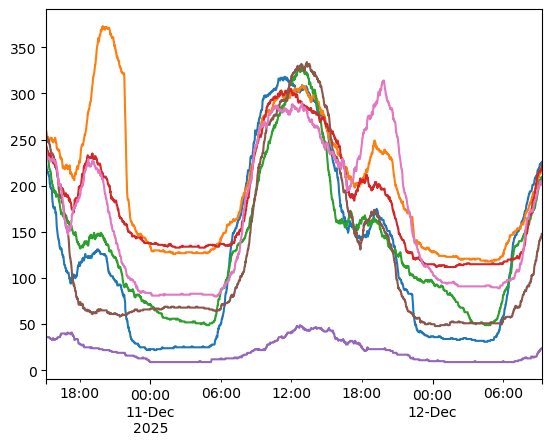

In [16]:
for gid in garages.keys():
    print(t[t['GarageID']==gid]['new_total'].plot())

In [17]:
t

,GarageID,transient,permit,employee,total,year,quarter,month,week,day,dayofyear,dayofweek,hour,hms,weekday_type,period,new_transient,new_permit,new_employee,new_total
2025-12-10 15:10:00,1,1,0,0,1,2025,4,12,50,10,344,2,15,15:10:00,1,Daytime,168,51,3,222
2025-12-10 15:11:00,1,-2,0,0,-2,2025,4,12,50,10,344,2,15,15:11:00,1,Daytime,165,51,3,219
2025-12-10 15:12:00,1,-4,0,0,-4,2025,4,12,50,10,344,2,15,15:12:00,1,Daytime,163,51,3,217
2025-12-10 15:13:00,1,-4,0,0,-4,2025,4,12,50,10,344,2,15,15:13:00,1,Daytime,163,51,3,217
2025-12-10 15:14:00,1,-4,0,0,-4,2025,4,12,50,10,344,2,15,15:14:00,1,Daytime,163,51,3,217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12 09:16:00,19,-39,3,1,-35,2025,4,12,50,12,346,4,9,09:16:00,1,Daytime,131,67,5,203
2025-12-12 09:17:00,19,-38,3,1,-34,2025,4,12,50,12,346,4,9,09:17:00,1,Daytime,132,67,5,204
2025-12-12 09:18:00,19,-37,3,1,-33,2025,4,12,50,12,346,4,9,09:18:00,1,Daytime,133,67,5,205
2025-12-12 09:19:00,19,-37,3,1,-33,2025,4,12,50,12,346,4,9,09:19:00,1,Daytime,133,67,5,205


In [18]:
current_state_of_visit_summary[current_state_of_visit_summary['GarageID']==18]

,GarageID,transient,permit,employee,total,year,quarter,month,week,day,dayofyear,dayofweek,hour,hms,weekday_type,period
date,,,,,,,,,,,,,,,,
2025-12-10 15:09:00,18,60,190,3,253,2025,4,12,50,10,344,2,15,15:09:00,1,Daytime


In [19]:
t[t['GarageID']==18]

,GarageID,transient,permit,employee,total,year,quarter,month,week,day,dayofyear,dayofweek,hour,hms,weekday_type,period,new_transient,new_permit,new_employee,new_total
2025-12-10 15:10:00,18,0,0,0,0,2025,4,12,50,10,344,2,15,15:10:00,1,Daytime,60,190,3,253
2025-12-10 15:11:00,18,0,-1,0,-1,2025,4,12,50,10,344,2,15,15:11:00,1,Daytime,60,189,3,252
2025-12-10 15:12:00,18,0,-1,0,-1,2025,4,12,50,10,344,2,15,15:12:00,1,Daytime,60,189,3,252
2025-12-10 15:13:00,18,1,-1,0,0,2025,4,12,50,10,344,2,15,15:13:00,1,Daytime,61,189,3,253
2025-12-10 15:14:00,18,0,-1,0,-1,2025,4,12,50,10,344,2,15,15:14:00,1,Daytime,60,189,3,252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12 09:16:00,18,-25,-83,1,-107,2025,4,12,50,12,346,4,9,09:16:00,1,Daytime,35,107,4,146
2025-12-12 09:17:00,18,-25,-81,1,-105,2025,4,12,50,12,346,4,9,09:17:00,1,Daytime,35,109,4,148
2025-12-12 09:18:00,18,-25,-81,1,-105,2025,4,12,50,12,346,4,9,09:18:00,1,Daytime,35,109,4,148
2025-12-12 09:19:00,18,-25,-81,1,-105,2025,4,12,50,12,346,4,9,09:19:00,1,Daytime,35,109,4,148


# Identify Insert and Update Types for dw.VisitDetails

In [20]:
cols = ['TripDetailID', 'TripDetailID_dw', 'GarageID', 'status', 'status_dw', 'TicketNumber', 'EntryDate', 'ExitDate', 'EntryDate_dw', 'length_of_stay', 'customer_type', '_merge', 'handler']

insert_cols = ['TripDetailID', 'GarageID', 'Garage', 'status', 'TicketNumber', 'EntryDate', 'ExitDate', 'length_of_stay', 'impute_duration', 'customer_type', 'exit_classification', 'TransactionType_exit', 'TicketType_entry', 'TicketTypeDesc_entry', 
          'TicketType_exit', 'TicketTypeDesc_exit', 'Parking_entry', 'Parking_exit', 'Amount', 'T2Amount', 'IdCashier', 'IdShift', 'EntryStation', 'ExitStation', 'ExitAttemptStation', 'PermitNumber', 'PermitName', 'GroupName',
          'CustomerName', 'CustomerID', 'SourceSystem', 'LoadDate']

In [21]:
dw_in_garage = pd.read_sql(f"""
    SELECT 
        *
    FROM dw.VisitDetails
    WHERE
        TicketNumber IN ({",".join([str(x) for x in e.TicketNumber.tolist()])})
        --TripDetailID IN ('{"','".join([str(x) for x in e.TripDetailID.tolist()])}')
        --ExitDate IS NULL
    """, cnxn.get_engine('PUReporting'))
dw_in_garage.shape

(1416, 32)

In [22]:
dw_in_garage

,TripDetailID,GarageID,Garage,status,TicketNumber,EntryDate,ExitDate,length_of_stay,impute_duration,customer_type,exit_classification,TransactionType_exit,TicketType_entry,TicketTypeDesc_entry,TicketType_exit,TicketTypeDesc_exit,Parking_entry,Parking_exit,Amount,T2Amount,IdCashier,IdShift,EntryStation,ExitStation,PermitNumber,PermitName,GroupName,CustomerName,CustomerID,SourceSystem,LoadDate,ExitAttemptStation
0,16B1EB51B9D48068CB261284DABAA901,18,Livingston,Complete,810000000,2025-08-11 17:18:55,2025-08-11 17:19:42,0.783333,NaN,permit,None,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,L300558130100,AMERICAN FAMILY\r\n,LTL - AmFam-Pay,LIVINGSTON Monthly Parkers,2050.0,ZMS,2025-08-24 18:06:19,None
1,1CA11E10CF5FD4DC520B008CE95C67B0,18,Livingston,Entry Only - Permit Holder,810422753,2025-12-10 09:39:54,NaT,NaN,NaN,permit,None,NaN,0.0,KP,NaN,None,90.0,NaN,NaN,NaN,NaN,NaN,E81,None,L300559550100,AMERICAN FAMILY \r\n,LTL - AmFam-Pay,LIVINGSTON Monthly Parkers,2050.0,ZMS,2025-12-10 15:10:22,None
2,1CABFC6091263DE50186DF96370A2BB4,18,Livingston,Entry Only - Permit Holder,810422719,2025-12-10 08:39:41,NaT,NaN,NaN,permit,None,NaN,0.0,KP,NaN,None,90.0,NaN,NaN,NaN,NaN,NaN,E81,None,L300553410100,AMERICAN FAMILY \r\n,LTL - AmFam-Pass,LIVINGSTON Monthly Parkers,2050.0,ZMS,2025-12-10 15:10:22,None
3,274AFD938381A7A32F1558F9216ACEAE,18,Livingston,Entry Only - Permit Holder,830158878,2025-12-10 08:35:24,NaT,NaN,NaN,permit,None,NaN,0.0,KP,NaN,None,90.0,NaN,NaN,NaN,NaN,NaN,E83,None,L300556110100,AMERICAN FAMILY \r\n,LTL - AmFam-Pay,LIVINGSTON Monthly Parkers,2050.0,ZMS,2025-12-10 15:10:22,None
4,2A30F3F9D22EF93ABC57E166617F0417,18,Livingston,Entry Only - Permit Holder,830158873,2025-12-10 08:16:46,NaT,NaN,NaN,permit,None,NaN,0.0,KP,NaN,None,90.0,NaN,NaN,NaN,NaN,NaN,E83,None,L300554090100,GOOGLE\r\n,LTL - GOOGLE,LIVINGSTON Monthly Parkers,2050.0,ZMS,2025-12-10 15:10:22,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411,F78104860DD560801EB20D4291BABC38,1,Overture Center,Entry Only,110107971,2025-12-10 09:27:48,NaT,204.000000,204.0,transient,imputed,NaN,0.0,KP,NaN,None,50.0,NaN,NaN,NaN,NaN,NaN,E11,None,None,None,None,None,NaN,ZMS,2025-12-10 15:10:13,None
1412,F8018B5FA9F4165DA6CAAB824842D76F,2,State St Capitol Upper,Entry Only - Permit Holder,241039974,2025-12-09 21:25:51,NaT,NaN,NaN,permit,None,NaN,0.0,KP,NaN,None,30.0,NaN,NaN,NaN,NaN,NaN,E24,None,L300213750100,SIERA\r\nBELLUE,SSCO-Upper-24/7,SSCO-Upper Monthly Parkers,2042.0,ZMS,2025-12-10 15:10:14,None
1413,FA5E0AC46655A7473A3A02498781F2F3,12,State St Capitol Lower,Entry Only,250296405,2025-12-10 11:14:32,NaT,204.000000,204.0,transient,imputed,NaN,0.0,KP,NaN,None,30.0,NaN,NaN,NaN,NaN,NaN,E25,None,None,None,None,None,NaN,ZMS,2025-12-10 15:10:21,None
1414,FE846F8BE67AC6AFE546F41A528FF165,5,Lake/Frances,Entry Only,420996842,2025-12-10 14:06:25,NaT,204.000000,204.0,transient,imputed,NaN,0.0,KP,NaN,None,70.0,NaN,NaN,NaN,NaN,NaN,E42,None,None,None,None,None,NaN,ZMS,2025-12-10 15:10:17,None


In [23]:
merged = e.merge(dw_in_garage, on='TicketNumber', how='left', indicator=True, suffixes=[None,'_dw'])
merged['handler'] = None

In [24]:
# UPDATE TYPE 1
# merge = both, status = Exit Only, status_dw is Entry Only/Entry Only - Permit
# update the dw by using TicketNumber, EntryDate
# could maybe ID this group by different TripDetailID
merged.loc[(merged['_merge']=='both') & (merged['status']=='Exit Only') & (merged['status_dw'].str.contains('Entry')), 'handler'] = 'update 1'
update_1 = merged[(merged['_merge']=='both') & (merged['status']=='Exit Only') & (merged['status_dw'].str.contains('Entry'))]
update_1[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,length_of_stay,customer_type,_merge,handler
0,15CF4CE27CD8DA0598AD0349ACD4555F,15CF4CE27CD8DA0598AD0349ACD4555F,2,Exit Only,Entry Only - Permit Holder,220999776,NaT,2025-12-10 17:52:14,2025-12-10 10:59:08,NaN,permit,both,update 1
1,C3C87E630BAFE97292FB5350E51D37C6,DF961EC853DE09E985A79E7B84175175,18,Exit Only,Entry Only,810422779,NaT,2025-12-10 16:48:14,2025-12-10 11:33:24,NaN,transient,both,update 1
2,43685A27EFC300E62D6D6D16ABF581CB,D7449D25E59CE6BB84CB033D0BE67249,5,Exit Only,Entry Only - Permit Holder,420996706,NaT,2025-12-10 17:42:04,2025-12-10 09:05:59,NaN,permit,both,update 1
3,B2944B4A3AE1C54B87E83C72ED31E1CA,259D3D529CF7C8C693B8F40AF88E74E8,6,Exit Only,Entry Only,620278504,NaT,2025-12-10 17:38:43,2025-12-10 09:05:11,NaN,transient,both,update 1
4,1852309AB1B3B985EBB463FDC3879ED3,1852309AB1B3B985EBB463FDC3879ED3,18,Exit Only,Entry Only - Permit Holder,830158898,NaT,2025-12-10 16:59:54,2025-12-10 09:17:36,NaN,permit,both,update 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338,7A3411D4DC70BAA1860FF3E6074D083C,7A6141C174558FF00DDB18680CA8D3B8,5,Exit Only,Entry Only - Permit Holder,410865634,NaT,2025-12-10 20:43:49,2025-12-10 04:26:58,NaN,permit,both,update 1
1339,274318517A2E087B42B6B538733A5136,A57A17E35EA0009BF5BAB14334CFF9D6,5,Exit Only,Entry Only,420996700,NaT,2025-12-10 15:57:30,2025-12-10 08:56:11,NaN,transient,both,update 1
1340,F0FE3F6DE3DE2552785B9755FD43913E,66AB15648309BA495DB536F5F5F3BAC3,6,Exit Only,Entry Only,610949143,NaT,2025-12-10 22:26:23,2025-12-10 14:05:35,NaN,transient,both,update 1
1341,E48D0C97443133CE779E5130B419F3C0,923F89AF29A74D63D414AE48791CD1B7,18,Exit Only,Entry Only - Permit Holder,810422731,NaT,2025-12-10 20:31:16,2025-12-10 08:59:10,NaN,permit,both,update 1


In [ ]:
# UPDATE TYPE 2
# Situation where dw knows of an Entry Only visit and there is now an Exit
# Most likely these are permit holders. That's how the query knows about the Entry, comes from PresenceSpmHistory
mask = (merged['_merge']=='both') & (merged['status']!='Exit Only') & (merged['EntryDate_dw'].notna()) & (merged['ExitDate'].notna())
merged.loc[mask, 'handler'] = 'update 2'
los = []
for item in (merged.loc[mask, 'ExitDate'] - merged.loc[mask, 'EntryDate_dw']):
    los.append(item.total_seconds()/60.)
merged.loc[mask, 'length_of_stay'] = los

# Exclude records the DW already has correct — already Complete with the same ExitDate
already_correct = (merged['status_dw'] == 'Complete') & (merged['ExitDate'] == merged['ExitDate_dw'])
update_2 = merged[mask & ~already_correct]
print(f"update_2: {len(update_2)} records need updating")
update_2[cols+['TransactionType_exit']]

In [26]:
# UPDATE TYPE 3
# Situation where dw knows of a Complete visit, current data sees Exit Only
# This seems unlikely to occur
# Do these need to be updated? I'm not sure they do. Doesn't seem like it. 
# Ok, it looks like one of them does need an update because when the data ran it only knew of a 40 exit. Now there is a 30 which is more accurate. 
merged.loc[(merged['_merge']=='both') & (merged['status']=='Exit Only') & (merged['status_dw']=='Complete') & (merged['ExitDate'].notna()), 'handler'] = 'update 3'
update_3 = merged[(merged['_merge']=='both') & (merged['status']=='Exit Only') & (merged['status_dw']=='Complete') & (merged['ExitDate'].notna())]
update_3[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,length_of_stay,customer_type,_merge,handler
294,4B7969B987C0B7E45714F4A4A1E37021,4A011C38686E16A95B0B3BDCF5C8801A,6,Exit Only,Complete,610948997,NaT,2025-12-10 15:10:01,2025-12-10 07:58:52,NaN,transient,both,update 3
630,306C6DE3AEA6B406DF13F28E9CFB8068,838F052692091252C9FD76862CE2CC96,19,Exit Only,Complete,710491995,NaT,2025-12-10 15:12:00,2025-12-10 06:26:39,NaN,transient,both,update 3
636,437969508163B84BAFF79C5C49A84C21,B419E0352499888BB37497F20A3472CC,19,Exit Only,Complete,730137786,NaT,2025-12-10 16:40:37,2023-06-24 15:38:15,NaN,transient,both,update 3
686,B1C2AC1AD4419E815F4677F3FC3FB277,AD8A3FD3CDAA1E7447FD8C4A8487985B,1,Exit Only,Complete,140367986,NaT,2025-12-11 11:17:48,2023-09-16 13:05:57,NaN,transient,both,update 3
773,2ECDE47DCC82EA3DD86FFA9F80CD8C2B,4CE0A3F8FD32C540EFF262041C2D5009,19,Exit Only,Complete,710492018,NaT,2025-12-10 15:10:09,2025-12-10 07:38:36,NaN,permit,both,update 3
780,597C7787913D5C450B31A9AD49348CC8,18D3AB7E7E53160A83F1E489C9226483,1,Exit Only,Complete,120740878,NaT,2025-12-10 15:11:43,2025-12-10 12:03:42,NaN,transient,both,update 3
872,2BDFA3AAD839826F64681C6607D7FE3B,D78B34F5460F39408201C6B83AB5BA45,1,Exit Only,Complete,120740738,NaT,2025-12-10 15:10:05,2025-12-10 06:34:48,NaN,transient,both,update 3
951,86EE97EF584C733EB741DAE55146923D,E11AB592793A5A23090F19EE31EBDFF2,2,Exit Only,Complete,241040084,NaT,2025-12-10 15:14:13,2025-12-10 14:42:24,NaN,transient,both,update 3
977,EA1877AE1C0E5A697034E1831718A1E5,EA1877AE1C0E5A697034E1831718A1E5,18,Exit Only,Complete,830158868,NaT,2025-12-10 15:10:12,2025-12-10 08:07:54,NaN,permit,both,update 3
1100,81A8C83B126EA5530098F301E712F789,008BF96FE32087EAA135E72A26AF95DA,19,Exit Only,Complete,730349666,NaT,2025-12-10 15:13:02,2025-12-10 09:58:56,NaN,transient,both,update 3


In [27]:
update_3[['ExitDate_dw', 'exit_classification', 'impute_duration', 'TransactionType_exit', 'TicketType_exit', 'TicketTypeDesc_exit', 'Parking_exit', 'Amount', 'T2Amount', 'IdCashier', 'IdShift', 'ExitStation', 'ExitAttemptStation', 'newLoadDate']]

,ExitDate_dw,exit_classification,impute_duration,TransactionType_exit,TicketType_exit,TicketTypeDesc_exit,Parking_exit,Amount,T2Amount,IdCashier,IdShift,ExitStation,ExitAttemptStation,newLoadDate
294,2025-12-10 15:10:01,manual: help line,None,30.0,0.0,KP,40.0,11.25,11.25,0.0,0.0,A61,None,2025-12-12 09:20:44.333322
630,2025-12-10 15:08:30,manual: help line,None,30.0,0.0,KP,14.0,0.00,14.00,0.0,0.0,K71,None,2025-12-12 09:20:44.333322
636,2023-06-24 22:00:15,lost ticket: POF,None,30.0,-1.0,lost ticket,1.0,0.00,30.00,0.0,0.0,K73,K73,2025-12-12 09:20:44.333322
686,2023-09-16 15:05:21,lost ticket: help line,None,30.0,-1.0,lost ticket,50.0,0.00,0.80,0.0,0.0,K14,K14,2025-12-12 09:20:44.333322
773,2025-12-10 15:10:09,manual: help line,None,30.0,0.0,KP,14.0,0.00,0.00,0.0,0.0,A72,None,2025-12-12 09:20:44.333322
780,2025-12-10 15:06:16,manual: help line,None,30.0,0.0,KP,50.0,0.00,5.60,0.0,0.0,K14,None,2025-12-12 09:20:44.333322
872,2025-12-10 15:10:05,manual: help line,None,30.0,0.0,KP,50.0,14.40,14.40,0.0,0.0,A12,A12,2025-12-12 09:20:44.333322
951,2025-12-10 15:08:14,None,None,30.0,0.0,KP,30.0,0.00,0.00,74.0,8573.0,E24,None,2025-12-12 09:20:44.333322
977,2025-12-10 15:10:12,manual: help line,None,30.0,0.0,KP,90.0,0.00,0.00,0.0,0.0,A83,None,2025-12-12 09:20:44.333322
1100,2025-12-10 15:08:57,manual: help line,None,30.0,0.0,KP,14.0,0.00,9.90,0.0,0.0,K73,None,2025-12-12 09:20:44.333322


In [28]:
# UPDATE TYPE 4
# Non-update or Imputation
# Situation where dw knows of an Entry Only visit, and there is still no known exit
# In theory, should not have data from warehouse, however, due I am rounding the start date down to the nearest minute so it's possible to get a couple from both sides
# *** Question is: When do we call it a day and impute length of stay and Exit Date? ***
merged.loc[(merged['_merge']=='both') & (merged['status'].str.contains('Entry')) & (merged['status_dw'].str.contains('Entry')) & (merged['ExitDate'].isna()), 'handler'] = 'update 4'
update_4 = merged[(merged['_merge']=='both') & (merged['status'].str.contains('Entry')) & (merged['status_dw'].str.contains('Entry')) & (merged['ExitDate'].isna())]
update_4[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,length_of_stay,customer_type,_merge,handler


In [29]:
# UPDATE TYPE 5
# Situation where there is no new data connecting to an existing dw entry, but it's been X days and it's time to manually close it with imputed data 
# Essentially, this could be a lost ticket situation. After some amount of time, we have to assume they're not in the garage anymore. 
# Had been saying if there was an entry from a prior day, we
pd.read_sql("""
    SELECT 
        *
    FROM dw.VisitDetails
    WHERE
        status LIKE 'Entry%'
        AND ExitDate IS NULL
        AND customer_type = 'transient'
        AND EntryDate <= DATEADD(day, -2, GETDATE()) -- Rethink the number of days.
        
    """, cnxn.get_engine('PUReporting'))

,TripDetailID,GarageID,Garage,status,TicketNumber,EntryDate,ExitDate,length_of_stay,impute_duration,customer_type,exit_classification,TransactionType_exit,TicketType_entry,TicketTypeDesc_entry,TicketType_exit,TicketTypeDesc_exit,Parking_entry,Parking_exit,Amount,T2Amount,IdCashier,IdShift,EntryStation,ExitStation,PermitNumber,PermitName,GroupName,CustomerName,CustomerID,SourceSystem,LoadDate,ExitAttemptStation
0,FF6EA60FCD33F86252629E1903EEA8C2,12,State St Capitol Lower,Entry Only,250296371,2025-12-10 07:54:44,None,204.0,204.0,transient,imputed,None,0,KP,None,None,30,None,None,None,None,None,E25,None,None,None,None,None,None,ZMS,2025-12-10 15:10:21,None
1,82B8749D3E2C374DD24213D97CB87E30,6,Capitol Square North,Entry Only,620278465,2025-12-10 07:06:22,None,204.0,204.0,transient,imputed,None,0,KP,None,None,40,None,None,None,None,None,E62,None,None,None,None,None,None,ZMS,2025-12-10 15:10:19,None
2,BE14F96DF07C6D0F86BBD113700E37FB,6,Capitol Square North,Entry Only,610948987,2025-12-10 07:46:50,None,204.0,204.0,transient,imputed,None,0,KP,None,None,40,None,None,None,None,None,E61,None,None,None,None,None,None,ZMS,2025-12-10 15:10:19,None
3,E8367CE34B0C7E4E639133240669FAAA,6,Capitol Square North,Entry Only,610949000,2025-12-10 08:02:21,None,204.0,204.0,transient,imputed,None,0,KP,None,None,40,None,None,None,None,None,E61,None,None,None,None,None,None,ZMS,2025-12-10 15:10:19,None
4,CE50EC1DD493B084C981F0BD40980D3B,6,Capitol Square North,Entry Only,610949016,2025-12-10 08:15:26,None,204.0,204.0,transient,imputed,None,0,KP,None,None,40,None,None,None,None,None,E61,None,None,None,None,None,None,ZMS,2025-12-10 15:10:19,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,47B41CDBB8255AB3DF43507FF4024892,19,Wilson Street,Entry Only,730349602,2025-12-10 08:11:55,None,204.0,204.0,transient,imputed,None,0,KP,None,None,14,None,None,None,None,None,E73,None,None,None,None,None,None,ZMS,2025-12-10 15:10:24,None
437,8678A3080DCB78DE080CB872CD611778,19,Wilson Street,Entry Only,730349612,2025-12-10 08:23:56,None,204.0,204.0,transient,imputed,None,0,KP,None,None,14,None,None,None,None,None,E73,None,None,None,None,None,None,ZMS,2025-12-10 15:10:24,None
438,BC524FCE40BFF8BBDE4DC138DD73AB75,19,Wilson Street,Entry Only,730349624,2025-12-10 08:41:07,None,204.0,204.0,transient,imputed,None,0,KP,None,None,14,None,None,None,None,None,E73,None,None,None,None,None,None,ZMS,2025-12-10 15:10:24,None
439,E3678387338687453BBF76DDD5F5C301,19,Wilson Street,Entry Only,710492071,2025-12-10 08:46:44,None,204.0,204.0,transient,imputed,None,0,KP,None,None,14,None,None,None,None,None,E71,None,None,None,None,None,None,ZMS,2025-12-10 15:10:24,None


In [30]:
# INSERT TYPE 1
# Situation where there is no existing data in warehouse to tie to, essentially the entry comes after the previous through date
# Entry exists, exit does not exist
merged.loc[(merged['_merge']=='left_only') & (merged['EntryDate'].notna()) & (merged['ExitDate'].isna()), 'handler'] = 'insert 1'
insert_1 = merged[(merged['_merge']=='left_only') & (merged['EntryDate'].notna()) & (merged['ExitDate'].isna())]
insert_1[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,length_of_stay,customer_type,_merge,handler
1390,A73579A869E6717B2B32487DE931BE58,NaN,2,Entry Only - Permit Holder,NaN,241040089,2025-12-10 15:32:16,NaT,NaT,NaN,permit,left_only,insert 1
1428,EF38EF551E362E7FE2A2A396860A21B1,NaN,5,Entry Only - Permit Holder,NaN,420996879,2025-12-10 15:51:37,NaT,NaT,NaN,permit,left_only,insert 1
1631,126A726A8ADE29AA0ABA9BD9C6A20487,NaN,2,Entry Only - Permit Holder,NaN,241040107,2025-12-10 17:03:52,NaT,NaT,NaN,permit,left_only,insert 1
1662,C7BD5834A73D6930331F05F16E827345,NaN,6,Entry Only - Permit Holder,NaN,620278545,2025-12-10 17:10:16,NaT,NaT,NaN,permit,left_only,insert 1
1908,4410962A194494215E2550B486FA7343,NaN,6,Entry Only - Permit Holder,NaN,610949233,2025-12-10 17:53:04,NaT,NaT,NaN,permit,left_only,insert 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7828,58F2D55F697322E590BB0160359360DE,NaN,19,Entry Only,NaN,710492876,2025-12-12 09:18:55,NaT,NaT,NaN,transient,left_only,insert 1
7829,BD1B22F4894CE82C3F6F13B9F8C9C8C8,NaN,6,Entry Only,NaN,610949769,2025-12-12 09:19:21,NaT,NaT,NaN,transient,left_only,insert 1
7830,587446E7D136C2E3DDD32A7A6576A1CA,NaN,6,Entry Only,NaN,610949770,2025-12-12 09:19:36,NaT,NaT,NaN,transient,left_only,insert 1
7831,ACC4D3CD32EAE19AC5195EAE8157EC9E,NaN,5,Entry Only,NaN,420997473,2025-12-12 09:19:39,NaT,NaT,NaN,transient,left_only,insert 1


In [31]:
# INSERT TYPE 2
# Situation where there is an entry and an exit and both occurred after the cutoff (nothing exists in the dw)
merged.loc[(merged['_merge']=='left_only') & (merged['status']=='Complete') & (merged['ExitDate'].notna()), 'handler'] = 'insert 2'
insert_2 = merged[(merged['_merge']=='left_only') & (merged['status']=='Complete') & (merged['ExitDate'].notna())]
insert_2[cols]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,length_of_stay,customer_type,_merge,handler
1345,FEF8382BA123ED000B34CFD31B112752,NaN,6,Complete,NaN,610949154,2025-12-10 15:12:38,2025-12-10 23:17:08,NaT,484.500000,transient,left_only,insert 2
1346,C6112479A3BCA0E0C0127D7FE6262F44,NaN,5,Complete,NaN,420996864,2025-12-10 15:12:48,2025-12-10 15:23:56,NaT,11.133333,transient,left_only,insert 2
1347,1037AF57F8FBFF1A3E552FC67EC15D1C,NaN,18,Complete,NaN,810422808,2025-12-10 15:13:31,2025-12-10 20:19:18,NaT,305.783333,transient,left_only,insert 2
1348,9F89D00B6950A6901B0DA57E5AF07576,NaN,2,Complete,NaN,220999827,2025-12-10 15:14:10,2025-12-10 15:52:12,NaT,38.033333,transient,left_only,insert 2
1349,3FA9D90E365C7F7B41C6DA19C42E54E2,NaN,1,Complete,NaN,140562209,2025-12-10 15:15:13,2025-12-10 22:16:52,NaT,421.650000,transient,left_only,insert 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7686,EB89E7454F10A1C038F0DCFBF121C0E6,NaN,12,Complete,NaN,250296569,2025-12-12 08:53:13,2025-12-12 09:03:44,NaT,10.516666,transient,left_only,insert 2
7691,7DAFE985EECB61E32E009B1B9DBCD718,NaN,19,Complete,NaN,710492870,2025-12-12 08:53:33,2025-12-12 09:16:08,NaT,22.583333,transient,left_only,insert 2
7720,65AFEC2EBD826E45FABBD8F2DF63AED0,NaN,18,Complete,NaN,820184405,2025-12-12 08:57:24,2025-12-12 09:04:07,NaT,6.716666,transient,left_only,insert 2
7759,57C4683306B4F84B32D3661A1ADF4D9F,NaN,5,Complete,NaN,410866554,2025-12-12 09:04:18,2025-12-12 09:07:04,NaT,2.766666,employee,left_only,insert 2


In [32]:
# INSERT TYPE 3
# Exit only, nothing connects in the warehouse, weird ticket number for which there is no corresponding 20
insert_3_mask = (merged['_merge']=='left_only') & (merged['status']=='Exit Only') & (merged['status_dw'].isna())
merged.loc[insert_3_mask, 'handler'] = 'insert 3'
insert_3 = merged[insert_3_mask].copy()
insert_3['EntryDate'] = insert_3['ExitDate'].apply(lambda x: x - timedelta(minutes=204))
insert_3['length_of_stay'] = 204
insert_3['impute_duration'] = 204
insert_3['TripDetailID'] = insert_3.apply(lambda row: sql_md5_hash(row['GarageID'], row['TicketNumber'], row['EntryDate']), axis=1)
insert_3[cols]

2025-12-11 08:14:27.000
2025-12-10 19:26:13.000
2025-12-11 07:48:03.000
2025-12-11 09:08:58.000
2025-12-10 14:33:36.000
2025-12-11 17:36:41.000
2025-12-11 12:14:39.000
2025-12-11 06:22:54.000
2025-12-10 12:00:05.000
2025-12-11 10:44:24.000
2025-12-11 10:30:38.000
2025-12-11 18:56:56.000
2025-12-11 11:51:32.000
2025-12-10 18:47:20.000
2025-12-11 04:11:52.000
2025-12-11 11:51:07.000
2025-12-11 06:20:23.000
2025-12-11 12:19:21.000
2025-12-11 11:47:04.000
2025-12-10 17:49:15.000
2025-12-11 11:48:01.000
2025-12-10 18:45:04.000


,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,length_of_stay,customer_type,_merge,handler
19,17D34B8DCA034803AD457D4F8362D512,NaN,1,Exit Only,NaN,110000091,2025-12-11 08:14:27,2025-12-11 11:38:27,NaT,204,transient,left_only,insert 3
60,9012A870CC8396278332E301FF65E116,NaN,2,Exit Only,NaN,230000431,2025-12-10 19:26:13,2025-12-10 22:50:13,NaT,204,transient,left_only,insert 3
239,61BAA525B766D0E3E4249261013FA7BC,NaN,12,Exit Only,NaN,250000517,2025-12-11 07:48:03,2025-12-11 11:12:03,NaT,204,transient,left_only,insert 3
309,6C9A7EEE927A4B3ACDCE2988F3372020,NaN,2,Exit Only,NaN,220004805,2025-12-11 09:08:58,2025-12-11 12:32:58,NaT,204,transient,left_only,insert 3
324,7C67306738C882B3510E640DD28F341B,NaN,1,Exit Only,NaN,130000086,2025-12-10 14:33:36,2025-12-10 17:57:36,NaT,204,transient,left_only,insert 3
405,7CFF7FB9FC901D463D906C26B2A47AB1,NaN,18,Exit Only,NaN,830000353,2025-12-11 17:36:41,2025-12-11 21:00:41,NaT,204,transient,left_only,insert 3
436,857FCA89D2942088F9BB162D1E979959,NaN,5,Exit Only,NaN,410004080,2025-12-11 12:14:39,2025-12-11 15:38:39,NaT,204,transient,left_only,insert 3
471,2347B8A0F8692BB020EEF7946950A151,NaN,19,Exit Only,NaN,710001021,2025-12-11 06:22:54,2025-12-11 09:46:54,NaT,204,transient,left_only,insert 3
621,523E0870BDD1459AF1A597F948D1874B,NaN,2,Exit Only,NaN,220004803,2025-12-10 12:00:05,2025-12-10 15:24:05,NaT,204,transient,left_only,insert 3
705,A365367626F2201CC63A818C03966228,NaN,2,Exit Only,NaN,220001391,2025-12-11 10:44:24,2025-12-11 14:08:24,NaT,204,transient,left_only,insert 3


In [33]:
# Will need to edit the dw where status is Exit Only
# UPDATE dw.VisitDetails SET TripDetailID = ... WHERE status = 'Exit Only'

In [33]:
# INSERT TYPE 4
# Similar to Type 3 except there is something in the dw. But that something is a weird ticket number and is clearly unrelated (for example, it comes from months or years earlier)
# Should ask Jon what's going on in this situaiton
# Treat it like an exit only, impute the EntryDate, length_of_stay, and 
insert_4_mask = (merged['_merge']=='both') & (merged['status']=='Exit Only') & (merged['status_dw']=='Exit Only') & (merged['ExitDate']!=merged['ExitDate_dw'])
merged.loc[insert_4_mask, 'handler'] = 'insert 4'
insert_4 = merged[insert_4_mask].copy()
insert_4['EntryDate'] = insert_4['ExitDate'].apply(lambda x: x - timedelta(minutes=204))
insert_4['length_of_stay'] = 204
insert_4['impute_duration'] = 204
#insert_4[cols+['ExitDate_dw', 'exit_classification']]
insert_4 = insert_4[insert_cols].drop_duplicates()
insert_4

,TripDetailID,GarageID,Garage,status,TicketNumber,EntryDate,ExitDate,length_of_stay,impute_duration,customer_type,exit_classification,TransactionType_exit,TicketType_entry,TicketTypeDesc_entry,TicketType_exit,TicketTypeDesc_exit,Parking_entry,Parking_exit,Amount,T2Amount,IdCashier,IdShift,EntryStation,ExitStation,ExitAttemptStation,PermitNumber,PermitName,GroupName,CustomerName,CustomerID,SourceSystem,LoadDate
197,0B05AB7E10BE26BD0D1A34BE972A4D8B,5,Lake/Frances,Exit Only,420001675,2025-12-11 11:18:14,2025-12-11 14:42:14,204,204,transient,lost ticket: POF,30.0,NaN,None,-1.0,lost ticket,NaN,1.0,0.0,30.0,0.0,0.0,None,K42,K42,None,None,None,None,NaN,ZMS,2025-12-12 09:21:19.430
274,08DA144588291F06E4EFF3CE22ACA85B,19,Wilson Street,Exit Only,720000339,2025-12-11 10:30:22,2025-12-11 13:54:22,204,204,transient,manual: help line,30.0,NaN,None,0.0,KP,NaN,14.0,2.7,2.7,0.0,0.0,None,A72,A72,None,None,None,None,NaN,ZMS,2025-12-12 09:21:19.430
321,50F15AC2A31B1369B96A6E7E0A3835F2,5,Lake/Frances,Exit Only,410000313,2025-12-11 23:38:43,2025-12-12 03:02:43,204,204,transient,lost ticket: POF,30.0,NaN,None,-1.0,lost ticket,NaN,1.0,0.0,30.0,0.0,0.0,None,K41,K41,None,None,None,None,NaN,ZMS,2025-12-12 09:21:19.430
607,380AC1BA13D676A232C5D296CBE010E1,5,Lake/Frances,Exit Only,420001235,2025-12-11 11:07:32,2025-12-11 14:31:32,204,204,transient,lost ticket: help line,30.0,NaN,None,0.0,KP,NaN,0.0,30.0,30.0,0.0,0.0,None,A42,A42,None,None,None,None,NaN,ZMS,2025-12-12 09:21:19.430
752,8514F61555EAFD810520DA9BBC1644A7,5,Lake/Frances,Exit Only,420001676,2025-12-11 12:12:25,2025-12-11 15:36:25,204,204,transient,lost ticket: POF,30.0,NaN,None,-1.0,lost ticket,NaN,1.0,0.0,30.0,0.0,0.0,None,K42,K42,None,None,None,None,NaN,ZMS,2025-12-12 09:21:19.430
1342,7985F8F7D87BBE9642CC0055F174A0F3,5,Lake/Frances,Exit Only,420001236,2025-12-11 21:48:25,2025-12-12 01:12:25,204,204,transient,lost ticket: help line,31.0,NaN,None,0.0,KP,NaN,0.0,30.0,30.0,0.0,0.0,None,None,E0,None,None,None,None,NaN,ZMS,2025-12-12 09:21:19.430


In [34]:
# INSERT TYPE 5
# An exit only exists in the DW already and both ExitDates are the same
# Should actually be an update, not an insert. And probably don't have anything to update. 
# These will need to get an imputed EntryDate at some point, but that should be handled by a separate process
insert_5_mask = (merged['_merge']=='both') & (merged['status']=='Exit Only') & (merged['status_dw']=='Exit Only') & (merged['ExitDate']==merged['ExitDate_dw'])
merged.loc[insert_5_mask, 'handler'] = 'insert 5'
insert_5 = merged[insert_5_mask].copy()
insert_5[cols+['ExitDate_dw']]

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,length_of_stay,customer_type,_merge,handler,ExitDate_dw


In [35]:
merged[merged['handler'].isna()][cols].sort_values('EntryDate')

,TripDetailID,TripDetailID_dw,GarageID,status,status_dw,TicketNumber,EntryDate,ExitDate,EntryDate_dw,length_of_stay,customer_type,_merge,handler


In [36]:
merged.handler.value_counts().sort_index()#.sum()

handler
insert 1    1105
insert 2    5197
insert 3      22
insert 4       7
update 1    1304
update 2     187
update 3      11
Name: count, dtype: int64

In [37]:
with cnxn.get_engine('PUReporting').begin() as conn:
    for i, rec in update_1.iterrows():
        stmt = text("""
                UPDATE dw.VisitDetails 
                SET 
                    status = 'Complete',
                    ExitDate = :ExitDate,
                    length_of_stay = DATEDIFF(second, EntryDate, :ExitDate)/60.,
                    impute_duration = NULL,
                    exit_classification = NULL,
                    TransactionType_exit = :TransactionType_exit,
                    TicketType_exit = :TicketType_exit,
                    TicketTypeDesc_exit = :TicketTypeDesc_exit,
                    Parking_exit = :Parking_exit,
                    Amount = :Amount,
                    T2Amount = :T2Amount,
                    IdCashier = :IdCashier,
                    IdShift = :IdShift,
                    ExitStation = :ExitStation,
                    ExitAttemptStation = :ExitAttemptStation,
                    -- permit data?
                    LoadDate = :newLoadDate
                WHERE 
                    TripDetailID = :TripDetailID_dw
                """
                )
        update_1_values = rec.to_dict()
        conn.execute(stmt, update_1_values)
    print('Success')

Success


In [ ]:
def to_sql_params(rec):
    """Convert a pandas Series row to a dict safe for pyodbc:
    - replaces NaN/NaT/pd.NA with None
    - converts numpy scalars to Python native types so pyodbc can infer SQL types correctly
    """
    result = {}
    for k, v in rec.items():
        if pd.isna(v):
            result[k] = None
        elif hasattr(v, 'item'):   # numpy scalar (int64, float64, etc.) → Python int/float
            result[k] = v.item()
        else:
            result[k] = v
    return result

# Bulk load update_2 into a staging table, then do a single UPDATE FROM JOIN.
# Far faster than one round-trip per row.
stage_cols = ['TripDetailID_dw', 'status', 'ExitDate', 'length_of_stay',
              'TransactionType_exit', 'TicketType_exit', 'TicketTypeDesc_exit',
              'Parking_exit', 'Amount', 'T2Amount', 'IdCashier', 'IdShift',
              'ExitStation', 'ExitAttemptStation', 'newLoadDate']

stage_df = pd.DataFrame([to_sql_params(rec) for _, rec in update_2[stage_cols].iterrows()])

engine = cnxn.get_engine('PUReporting')
with engine.begin() as conn:
    stage_df.to_sql('_update2_stage', schema='dw', con=conn,
                    if_exists='replace', index=False, chunksize=1000)

    conn.execute(text("""
        UPDATE v SET
            v.status                = s.status,
            v.ExitDate              = s.ExitDate,
            v.length_of_stay        = s.length_of_stay,
            v.impute_duration       = NULL,
            v.exit_classification   = NULL,
            v.TransactionType_exit  = s.TransactionType_exit,
            v.TicketType_exit       = s.TicketType_exit,
            v.TicketTypeDesc_exit   = s.TicketTypeDesc_exit,
            v.Parking_exit          = s.Parking_exit,
            v.Amount                = s.Amount,
            v.T2Amount              = s.T2Amount,
            v.IdCashier             = s.IdCashier,
            v.IdShift               = s.IdShift,
            v.ExitStation           = s.ExitStation,
            v.ExitAttemptStation    = s.ExitAttemptStation,
            v.LoadDate              = s.newLoadDate
        FROM dw.VisitDetails v
        JOIN dw._update2_stage s ON v.TripDetailID = s.TripDetailID_dw
    """))

    conn.execute(text("DROP TABLE dw._update2_stage"))
    print(f"Success — updated {len(stage_df)} records")

In [ ]:
with cnxn.get_engine('PUReporting').begin() as conn:
    for i, rec in update_3.iterrows():
        stmt = text("""
                UPDATE dw.VisitDetails 
                SET 
                    status = 'Complete',
                    ExitDate = :ExitDate,
                    length_of_stay = DATEDIFF(second, :EntryDate_dw, :ExitDate)/60.,
                    impute_duration = NULL,
                    exit_classification = NULL,
                    TransactionType_exit = :TransactionType_exit,
                    TicketType_exit = :TicketType_exit,
                    TicketTypeDesc_exit = :TicketTypeDesc_exit,
                    Parking_exit = :Parking_exit,
                    Amount = :Amount,
                    T2Amount = :T2Amount,
                    IdCashier = :IdCashier,
                    IdShift = :IdShift,
                    ExitStation = :ExitStation,
                    ExitAttemptStation = :ExitAttemptStation,
                    -- permit data?
                    LoadDate = :newLoadDate
                WHERE 
                    TripDetailID = :TripDetailID_dw
                """
                )
        update_3_values = rec.to_dict()
        #print(update_3_values)
        conn.execute(stmt, update_3_values)
    print('Success')

In [ ]:
# Inserts new data

# Combine your dataframes
df_to_insert = pd.concat([insert_1, insert_2, insert_3, insert_4])[insert_cols]

# Use a transaction context for automatic rollback on error
try:
    with cnxn.get_engine('PUReporting').begin() as conn:
        df_to_insert.to_sql(
            'VisitDetails', 
            schema='dw', 
            con=conn,  # Use the connection, not engine
            if_exists='append', 
            index=False, 
            chunksize=1000
        )
        # Transaction automatically commits if no exception occurs
        print(f"Successfully inserted {len(df_to_insert)} rows")
        
except Exception as e:
    # Transaction automatically rolls back on exception
    print(f"Error occurred, rolling back: {e}")
    raise  # Re-raise if you want the error to propagate

    #pd.concat([insert_1, insert_2, insert_3, insert_4])[insert_cols].to_sql('VisitDetails', schema='dw', con=cnxn.get_engine('PUReporting'), if_exists='append', index=False, chunksize=1000)

In [ ]:
load_summary(t, utils['start_date_by_garage'])